In [6]:
import sys, importlib.util

print("커널 파이썬:", sys.executable)
print("statsmodels 위치:", importlib.util.find_spec("statsmodels"))

커널 파이썬: c:\Users\Administrator\Desktop\Posco K New Deal\.venv\Scripts\python.exe
statsmodels 위치: ModuleSpec(name='statsmodels', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000019C03011550>, origin='c:\\Users\\Administrator\\Desktop\\Posco K New Deal\\.venv\\Lib\\site-packages\\statsmodels\\__init__.py', submodule_search_locations=['c:\\Users\\Administrator\\Desktop\\Posco K New Deal\\.venv\\Lib\\site-packages\\statsmodels'])


In [7]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## **실습 6 - 시계열 분해 시연·관찰**
원본·추세·주기·나머지 네 부분으로 분해해 관찰

목표
- 시계열을 원본·추세·주기·나머지 네 부분으로 분해해 관찰(강사 시연)

단계
- 분해 도구로 시각 데이터를 더하기 모형으로 분해
- 원본·추세·계절·잔차 네 칸을 함께 보기
- 추세 칸이 이동평균 추세와 비슷한지 비교

예상 결과
- 네 칸으로 나뉜 분해 결과 — 추세는 상승, 주기는 반복 무늬

shape: (192, 5)
기간: 2024-01-01 00:00:00 ~ 2024-01-08 23:00:00
결측: 0
이론상 시각: 192 | 실제 행: 192 | 빠진 시각: 0


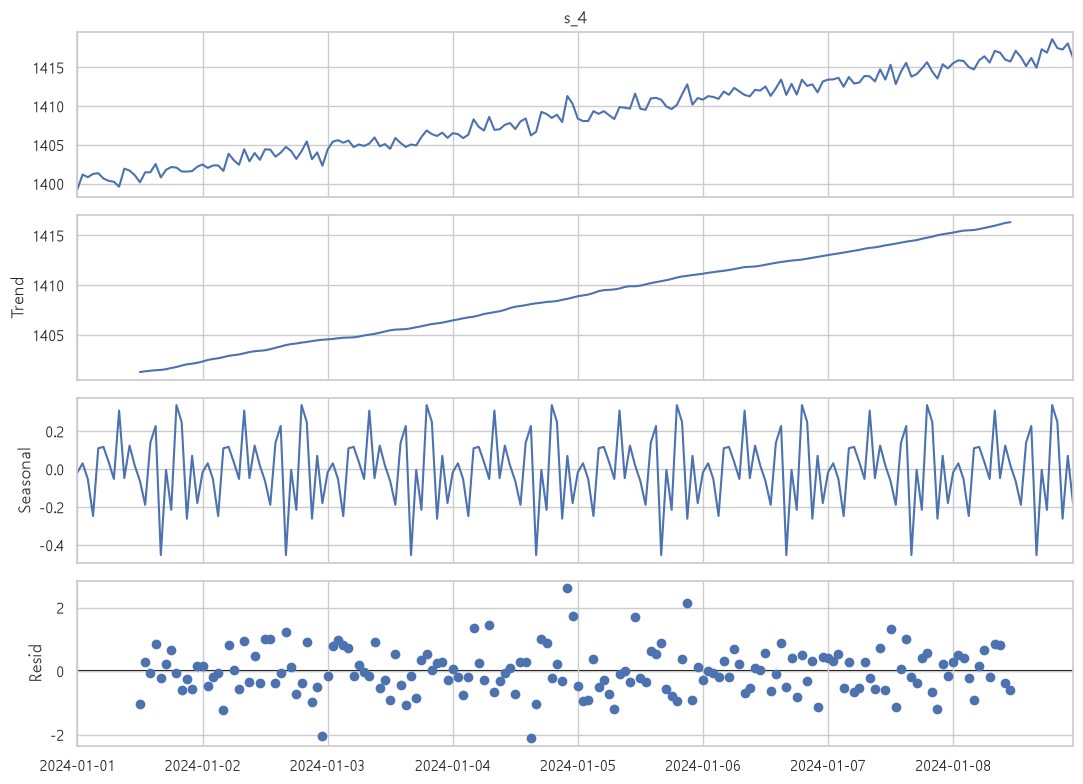

In [8]:
# 분해 도구로 시각 데이터를 더하기 모형으로 분해
# seasonal_decompose는 결측이 있으면 에러를 내므로 먼저 결측부터 확인한다
from statsmodels.tsa.seasonal import seasonal_decompose

ts_6 = pd.read_csv("..\\Data\\21_engine1_timestamp_sample.csv")
ts_6["timestamp"] = pd.to_datetime(ts_6["timestamp"])
ts_6 = ts_6.set_index("timestamp").sort_index()

print("shape:", ts_6.shape)
print("기간:", ts_6.index[0], "~", ts_6.index[-1])
print("결측:", ts_6.isna().sum().sum())

# 시각이 통째로 빠진 구간이 있는지도 확인 (있으면 resample + interpolate 필요)
전체시각_6 = pd.date_range(ts_6.index[0], ts_6.index[-1], freq="1h")
print("이론상 시각:", len(전체시각_6), "| 실제 행:", len(ts_6), "| 빠진 시각:", len(전체시각_6) - len(ts_6))

# period=24 : 1시간 간격 데이터에서 하루(24시간) 주기가 반복된다고 알려주는 값
# model="additive" : 원본 = 추세 + 계절 + 잔차 로 본다는 뜻
result_6 = seasonal_decompose(ts_6["s_4"], model="additive", period=24)

# 원본, 추세, 계절, 잔차 네 칸을 함께 보기
fig = result_6.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.show()

In [9]:
# 네 성분을 숫자로 확인
print("[성분별 요약]")
for 이름, 성분 in [("trend", result_6.trend), ("seasonal", result_6.seasonal), ("resid", result_6.resid)]:
    print(f"{이름:9} NaN {성분.isna().sum():3}개 | 범위 {성분.min():9.3f} ~ {성분.max():9.3f} | 표준편차 {성분.std():7.3f}")

print()
print("원본 표준편차:", round(ts_6["s_4"].std(), 3))

# additive 모형이 맞는지 검증 - 세 성분을 더하면 원본이 나와야 한다
합_6 = result_6.trend + result_6.seasonal + result_6.resid
비교_6 = pd.DataFrame({"원본": ts_6["s_4"], "성분합": 합_6}).dropna()
print()
print("추세 + 계절 + 잔차 == 원본 인가?:", np.allclose(비교_6["원본"], 비교_6["성분합"]))
print(비교_6.head(3).round(4))

# 추세 앞뒤가 비어 있는 이유
# 추세는 24시간 중심 이동평균이라 앞 12칸, 뒤 12칸을 계산할 수 없다
print()
print("추세 첫 유효 시각:", result_6.trend.first_valid_index())
print("추세 끝 유효 시각:", result_6.trend.last_valid_index())
print("유효 구간:", result_6.trend.notna().sum(), "/", len(result_6.trend))

[성분별 요약]
trend     NaN  24개 | 범위  1401.277 ~  1416.340 | 표준편차   4.370
seasonal  NaN   0개 | 범위    -0.453 ~     0.338 | 표준편차   0.189
resid     NaN  24개 | 범위    -2.105 ~     2.612 | 표준편차   0.713

원본 표준편차: 5.044

추세 + 계절 + 잔차 == 원본 인가?: True
                          원본      성분합
timestamp                            
2024-01-01 12:00:00  1400.19  1400.19
2024-01-01 13:00:00  1401.46  1401.46
2024-01-01 14:00:00  1401.48  1401.48

추세 첫 유효 시각: 2024-01-01 12:00:00
추세 끝 유효 시각: 2024-01-08 11:00:00
유효 구간: 168 / 192


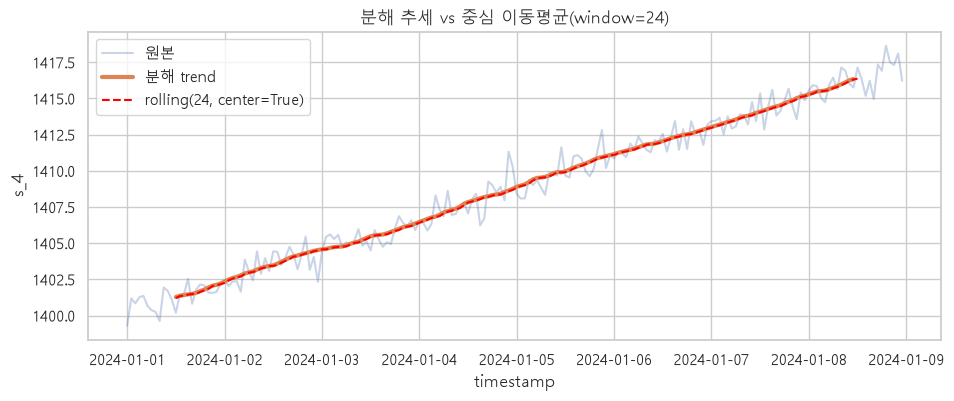

두 선의 상관계수: 1.0


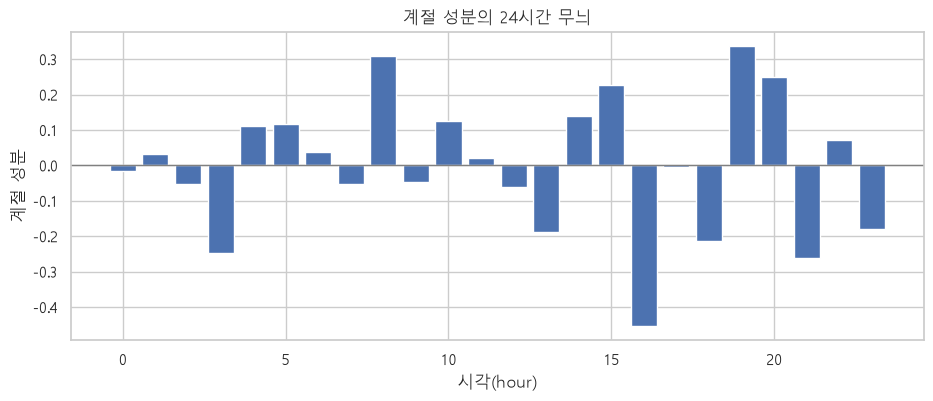


계절 성분 진폭: 0.791
원본 대비 비중: 3.7 %


In [11]:
# 추세 칸이 이동평균 추세와 비슷한지 비교
# seasonal_decompose의 추세는 "중심 이동평균"이라 rolling(center=True)와 같아야 한다
ma24_6 = ts_6["s_4"].rolling(window=24, center=True).mean()

plt.figure(figsize=(11, 4))
plt.title("분해 추세 vs 중심 이동평균(window=24)")
plt.plot(ts_6.index, ts_6["s_4"], alpha=0.3, label="원본")
plt.plot(result_6.trend.index, result_6.trend, linewidth=3, label="분해 trend")
plt.plot(ma24_6.index, ma24_6, linewidth=1.5, linestyle="--", color="red", label="rolling(24, center=True)")
plt.xlabel("timestamp")
plt.ylabel("s_4")
plt.legend()
plt.show()

print("두 선의 상관계수:", round(result_6.trend.corr(ma24_6), 4))

# 계절 성분이 실제로 하루 주기 무늬인지 시간대별로 확인
계절_6 = result_6.seasonal.groupby(result_6.seasonal.index.hour).first()
plt.figure(figsize=(11, 4))
plt.title("계절 성분의 24시간 무늬")
plt.bar(계절_6.index, 계절_6.values)
plt.axhline(0, color="gray", linewidth=1)
plt.xlabel("시각(hour)")
plt.ylabel("계절 성분")
plt.show()

print()
print("계절 성분 진폭:", round(계절_6.max() - 계절_6.min(), 3))
print("원본 대비 비중:", round(result_6.seasonal.std() / ts_6["s_4"].std() * 100, 1), "%")

# [관찰]
# 추세는 1401.28 -> 1416.34로 8일 내내 상승 (원본 흔들림의 대부분을 설명, std 4.370)
# 분해 trend와 rolling(24, center=True)의 상관이 1.0 -> 둘은 사실상 같은 계산이다
# 계절 성분은 진폭 0.79, 원본 대비 3.7%로 매우 작다
#   -> 이 데이터에는 "하루 주기 무늬"가 사실상 없고, period=24는 우리가 가정으로 넣은 값일 뿐
#   -> 잔차(std 0.713)가 계절(std 0.189)보다 훨씬 크다는 것도 같은 이야기
# [정리] 이 센서는 주기성 없이 꾸준히 상승하는 열화 신호 + 무작위 잡음으로 이루어져 있다